# Assignment 2

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Linear Regression

Let's set up our workspace and use the **Auto MPG dataset**. This dataset contains several features (such as horsepower, weight, displacement, and acceleration) and a target variable indicating the car's **miles per gallon (MPG)**.

Here, we will model **MPG (continuous outcome)** based on the car's physical and performance characteristics.

In [17]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [18]:
import seaborn as sns

# Load the Auto MPG dataset
mpg_data = sns.load_dataset('mpg')

# Drop rows with missing values
mpg_data = mpg_data.dropna(subset=['mpg', 'horsepower', 'weight', 'displacement'])

# Display the DataFrame
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


#### **Question 1:**  
#### Data inspection

Before fitting any model, it is essential to understand our data. **Use Python code** to answer the following questions about the **Auto MPG dataset**:

_(i)_ How many observations (rows) does the dataset contain and also how many variables (columns) does the dataset contain?

In [19]:
# Your answer here...
#rows, columns = mpg_data.shape
print("Number of Rows:", mpg_data.shape[0])
print("Number of Columns:", mpg_data.shape[1])

Number of Rows: 392
Number of Columns: 9


_(ii)_ What is the 'variable type' of the response variable `mpg` (e.g., 'integer', 'category', etc.) and explain what it is in short? (1-2 sentences at max)

In [20]:
# Your answer here...
print("The variable type of mpg is:", mpg_data['mpg'].dtype)


The variable type of mpg is: float64


Explanation: mpg represents miles per gallon and is stored in float64 type which represents a 64-bit floating point number 
used to store numerical values with decimal points, enabling high precision in calculations and representation of continuous data.

_(iii)_ Find the 5 rows with the greatest `horsepower`.

In [21]:
# Your answer here... 
print(mpg_data.nlargest(5, 'horsepower'))

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
116  16.0          8         400.0       230.0    4278           9.5   
8    14.0          8         455.0       225.0    4425          10.0   
13   14.0          8         455.0       225.0    3086          10.0   
95   12.0          8         455.0       225.0    4951          11.0   
6    14.0          8         454.0       220.0    4354           9.0   

     model_year origin                      name  
116          73    usa        pontiac grand prix  
8            70    usa          pontiac catalina  
13           70    usa   buick estate wagon (sw)  
95           73    usa  buick electra 225 custom  
6            70    usa          chevrolet impala  


_(iv)_ How many predictor variables do we have (Hint: all variables other than `mpg`)?

In [22]:
# Your answer here...
print("The number of predictor variables is:", mpg_data.shape[1] -1)

The number of predictor variables is: 8


You can use `print()` and `describe()` to help answer these questions.

#### **Question 2:** 
#### Data-visualization

Before we fit and review model outputs, we should visualize our data. Review the code and plot, shown below.

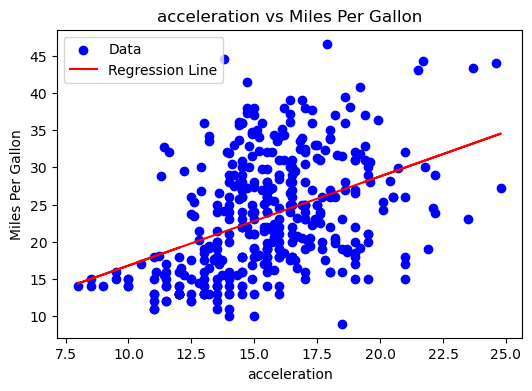

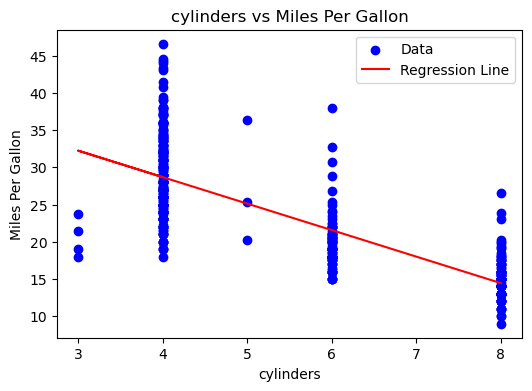

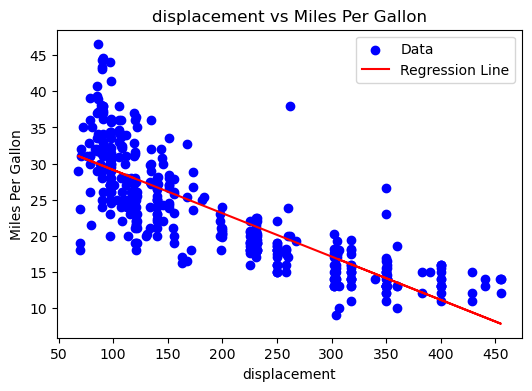

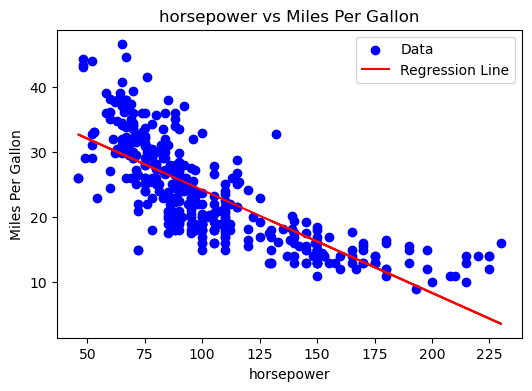

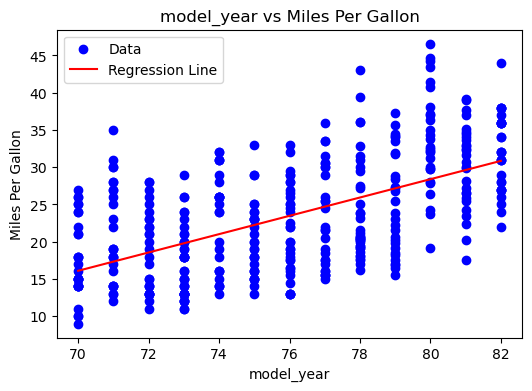

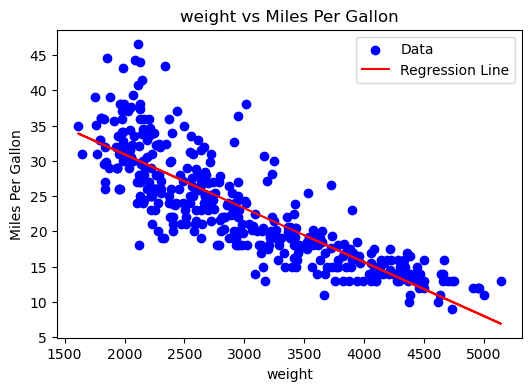

In [23]:
# Exclude the 'mpg' (target variable) and non-numeric columns from the feature names
feature_names = mpg_data.select_dtypes(include=[float, int]).columns.difference(['mpg'])

# Loop through each numeric feature (column) in mpg_data
for feature in feature_names:
    # Extract the feature column and target variable (mpg)
    X_feature = mpg_data[[feature]].values  # Extract as a 2D array
    y = mpg_data['mpg'].values  # Target variable (mpg)
    
    # Create a scatter plot for the feature against the target (mpg)
    plt.figure(figsize=(6, 4))
    plt.scatter(X_feature, y, label='Data', color='blue')

    # Fit a linear regression model
    lm = LinearRegression()
    lm.fit(X_feature, y)

    # Plot the regression line
    plt.plot(X_feature, lm.predict(X_feature), color='red', label='Regression Line')

    # Add labels and title
    plt.xlabel(feature)
    plt.ylabel('Miles Per Gallon')
    plt.title(f'{feature} vs Miles Per Gallon')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

Answer the following questions:

_(i)_ Describe the associations being plotted ? (i.e., positive association, negative association, no association)

> Answer:
1. The first scatter plot with positive slope of the regression line illustrates the positive association between miles per gallon (mpg) and acceleration, which means the higher the acceleration, the higher the mpg consumption.

2. The second scatter plot with negative slope of the regression line illustrates the negative association between miles per gallon (mpg) and cylinders, which means the higher the number of cylinders, the lower the mpg consumption.

3. The third scatter plot with negative slope of the regression line illustrates the negative association between miles per gallon (mpg) and displacement, which means the higher the engine displacement, the lower the mpg consumption.

4. The fourth scatter plot with negative slope of the regression line illustrates the negative association between miles per gallon (mpg) and horsepower, which means the higher the horsepower, the lower the mpg consumption.

5. The fifth scatter plot with positive slope of the regression line illustrates the positive association between miles per gallon (mpg) and model year, which means later models have higher mpg consumption.

6. The sixth scatter plot with negative slope of the regression line illustrates the negative association between miles per gallon (mpg) and weight, which means the higher the weight, the lower the mpg consumption.

_(ii)_ What concept ‘defines’ the plotted line?

> Answer: The plotted line is defined by the concept of linear regression. It best fits a straight line to minimize the sum of squared residuals, i.e., the differences between observed and predicted values.

_(iii)_ Do all data points in the dataset fall perfectly along the plotted line? If not, why might there be deviations between the data points and the line, and what do these deviations indicate about the relationship between the variables?

> Answer: No, not all data points fall perfectly along the plotted line. The deviations known as residuals occur due to outliers due to noise or data variability causing features not always be captured by the predictor variables, non-lineral relationship between the predictor and response variables, discarded or overlooked data points due to data collection criteria and/or during data cleaning.

#### **Question 3:**  
#### Model fit  
Now, let’s fit a multivariable linear regression model using the general syntax `lm()`. As above, use **mpg** as the response variable **Y**, and all other variables as the predictors.

**Step 1: Split the dataset into train and test sets, using a 75-25 split. (use random_state=42)**

In [24]:
# Your answer here...

# Split the dataset into train and test sets (75-25 split, random_state=42)
mpg_data_train, mpg_data_test = train_test_split(mpg_data, train_size=0.75, random_state=42)

mpg_data_train.info()
mpg_data_test.info()

# Output the shapes of the train and test sets
print("mpg_data_train shape:", mpg_data_train.shape)
print("mpg_data_test shape:", mpg_data_test.shape)


<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 267 to 103
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           294 non-null    float64
 1   cylinders     294 non-null    int64  
 2   displacement  294 non-null    float64
 3   horsepower    294 non-null    float64
 4   weight        294 non-null    int64  
 5   acceleration  294 non-null    float64
 6   model_year    294 non-null    int64  
 7   origin        294 non-null    object 
 8   name          294 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 23.0+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 79 to 105
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           98 non-null     float64
 1   cylinders     98 non-null     int64  
 2   displacement  98 non-null     float64
 3   horsepower    98 non-null     float64
 4   w

**Step 2: Fit the linear regression model.**

In [25]:
# Your code here ...

#Select numeric predictors only and drop the response variable for the training set
X_train = mpg_data_train.select_dtypes(include=[float, int]).drop(columns=['mpg'])

#Select the response variable for the training set
y_train = mpg_data_train['mpg']

lm = LinearRegression()

lm.fit(X_train, y_train)

coefficients_df = pd.DataFrame({
    "predictor": X_train.columns,
    "slope": lm.coef_,
    "intercept": [lm.intercept_] * len(lm.coef_)
})

print(coefficients_df)

# lm.coef_ gives the coefficients for each predictor (change in miles per gallon per unit change in each predictor variable)
# lm.intercept_ gives the intercept b0 (the predicted miles per gallon when all predictors are set to 0)

      predictor     slope  intercept
0     cylinders -0.160143 -15.047371
1  displacement  0.000373 -15.047371
2    horsepower -0.001899 -15.047371
3        weight -0.006457 -15.047371
4  acceleration  0.057588 -15.047371
5    model_year  0.762270 -15.047371


#### **Question 4:** 
#### RMSPE
**Step 3. Finally, we predict on the test data set to assess how well our model does.** 

We will evaluate our final model's test error measured by RMSPE.

In [26]:

#Select numeric predictors only and drop the response variable for the test set
X_test = mpg_data_test.select_dtypes(include=[float, int]).drop(columns=['mpg'])

#Select the response variable for the test set
y_test = mpg_data_test['mpg']

# Predict the response variable on the test data
y_pred = lm.predict(X_test)

# Calculate RMSPE
rmspe = mean_squared_error(
    y_test,y_pred
)**0.5

# Display the RMSPE
print("RMSPE: {:.2f}%".format(rmspe))

RMSPE: 3.19%


# Criteria

| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is inspected for the number of variables, observations, and data types. | Data inspection is missing or incomplete.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots, histograms) are properly interepreted to explore the relationships between variables. | Data visualization were not correctly interpreted. |
| **Model Initialization**                               | The linear regression model is correctly initialized.            | The linear regression model is not initialized or is incorrect. |
| **Model Evaluation on Test Data**                      | The model is evaluated on the test data using appropriate metrics (e.g., RMSE). | The model evaluation is missing or uses the wrong metric. |


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 01/19/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [X] Created a branch with the correct naming convention.
- [X] Ensured that the repository is public.
- [X] Reviewed the PR description guidelines and adhered to them.
- [X] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-4-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
